# CMS Hospital Rating Analysis
Udacity Data Science Nanodegree - Project 1

This project analyzes hospital quality metrics from CMS to understand what factors influence hospital overall ratings.

## Business Questions

This analysis aims to answer the following questions:

1. **What factors influence hospital ratings?**

2. **Can hospital ratings be predicted using hospital quality metrics?**

3. **Which hospital performance indicators are most important for predicting ratings?**

In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


In [134]:
def load_data(path):
    """
    Load a CSV dataset from the given file path.

    Args:
        path (str): Path to the CSV file.

    Returns:
        pd.DataFrame: Loaded dataset.
    """
    return pd.read_csv(path)


def replace_not_available(data, missing_value="Not Available"):
    """
    Replace placeholder missing values with NaN.

    Args:
        data (pd.DataFrame): Input dataset.
        missing_value (str): Placeholder used for missing values.

    Returns:
        pd.DataFrame: Dataset with placeholder values replaced by NaN.
    """
    return data.replace(missing_value, np.nan)


def convert_columns_to_numeric(data, columns):
    """
    Convert selected columns to numeric dtype.

    Args:
        data (pd.DataFrame): Input dataset.
        columns (list): List of column names to convert.

    Returns:
        pd.DataFrame: Dataset with selected columns converted to numeric.
    """
    data = data.copy()
    for col in columns:
        data[col] = pd.to_numeric(data[col])
    return data


def drop_missing_rows(data, columns):
    """
    Remove rows with missing values in selected columns.

    Args:
        data (pd.DataFrame): Input dataset.
        columns (list): Columns that must not contain missing values.

    Returns:
        pd.DataFrame: Filtered dataset without missing values in selected columns.
    """
    return data.dropna(subset=columns)


def plot_count_distribution(data, column, title, xlabel, ylabel):
    """
    Plot a count distribution for a categorical or discrete variable.

    Args:
        data (pd.DataFrame): Input dataset.
        column (str): Column to visualize.
        title (str): Plot title.
        xlabel (str): Label for x-axis.
        ylabel (str): Label for y-axis.

    Returns:
        None
    """
    plt.figure(figsize=(6, 4))
    sns.countplot(x=data[column])
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()


def plot_correlation_heatmap(data, title):
    """
    Plot a correlation heatmap for a numeric dataset.

    Args:
        data (pd.DataFrame): Numeric dataset used to compute correlations.
        title (str): Plot title.

    Returns:
        None
    """
    corr = data.corr()
    plt.figure(figsize=(10, 7))
    sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
    plt.title(title)
    plt.show()


def train_random_forest(X_train, y_train, random_state=42):
    """
    Train a Random Forest classifier.

    Args:
        X_train (pd.DataFrame): Training features.
        y_train (pd.Series): Training target values.
        random_state (int): Random seed for reproducibility.

    Returns:
        RandomForestClassifier: Trained model.
    """
    model = RandomForestClassifier(random_state=random_state)
    model.fit(X_train, y_train)
    return model


def plot_conf_matrix(y_true, y_pred, title):
    """
    Plot a confusion matrix for classification results.

    Args:
        y_true (pd.Series): True target values.
        y_pred (np.ndarray): Predicted target values.
        title (str): Plot title.

    Returns:
        None
    """
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted Rating")
    plt.ylabel("Actual Rating")
    plt.show()


def get_feature_importance(model, feature_names):
    """
    Extract and sort feature importance values from a trained model.

    Args:
        model: Trained machine learning model with feature_importances_ attribute.
        feature_names (list): Feature names used in training.

    Returns:
        pd.Series: Sorted feature importance values.
    """
    importance = pd.Series(model.feature_importances_, index=feature_names)
    return importance.sort_values(ascending=False)


def plot_feature_importance(importance, title):
    """
    Plot feature importance scores.

    Args:
        importance (pd.Series): Feature importance values.
        title (str): Plot title.

    Returns:
        None
    """
    plt.figure(figsize=(8, 5))
    importance.sort_values().plot(kind="barh")
    plt.title(title)
    plt.xlabel("Importance Score")
    plt.ylabel("Features")
    plt.show()

In [159]:
df = load_data("data/Hospital_General_Information.csv")

In [160]:
df.head()

,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Hospital Type,Hospital Ownership,...,Count of READM Measures Better,Count of READM Measures No Different,Count of READM Measures Worse,READM Group Footnote,Pt Exp Group Measure Count,Count of Facility Pt Exp Measures,Pt Exp Group Footnote,TE Group Measure Count,Count of Facility TE Measures,TE Group Footnote
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Acute Care Hospitals,Government - Hospital District or Authority,...,0,11,0,NaN,8,8,NaN,12,11,NaN
1,010005,MARSHALL MEDICAL CENTERS,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,(256) 593-8310,Acute Care Hospitals,Government - Hospital District or Authority,...,0,8,1,NaN,8,8,NaN,12,12,NaN
2,010006,NORTH ALABAMA MEDICAL CENTER,1701 VETERANS DRIVE,FLORENCE,AL,35630,LAUDERDALE,(256) 768-8400,Acute Care Hospitals,Proprietary,...,0,8,1,NaN,8,8,NaN,12,10,NaN
3,010007,MIZELL MEMORIAL HOSPITAL,702 N MAIN ST,OPP,AL,36467,COVINGTON,(334) 493-3541,Acute Care Hospitals,Voluntary non-profit - Private,...,0,7,0,NaN,8,8,NaN,12,7,NaN
4,010008,CRENSHAW COMMUNITY HOSPITAL,101 HOSPITAL CIRCLE,LUVERNE,AL,36049,CRENSHAW,(334) 335-3374,Acute Care Hospitals,Proprietary,...,0,2,0,NaN,8,Not Available,5.0,12,6,NaN


In [161]:
df.shape

(5426, 38)

In [162]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5426 entries, 0 to 5425
Data columns (total 38 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Facility ID                                       5426 non-null   object 
 1   Facility Name                                     5426 non-null   object 
 2   Address                                           5426 non-null   object 
 3   City/Town                                         5426 non-null   object 
 4   State                                             5426 non-null   object 
 5   ZIP Code                                          5426 non-null   int64  
 6   County/Parish                                     5426 non-null   object 
 7   Telephone Number                                  5426 non-null   object 
 8   Hospital Type                                     5426 non-null   object 
 9   Hospital Ownership 

In [163]:
df.describe()

,ZIP Code,MORT Group Footnote,READM Group Footnote,Pt Exp Group Footnote,TE Group Footnote
count,5426.000000,1787.000000,1160.000000,2275.000000,940.000000
mean,53785.590675,11.581981,15.124138,10.162198,17.493617
std,27067.251164,7.057385,6.378223,6.808834,4.536324
min,603.000000,5.000000,5.000000,5.000000,5.000000
25%,32782.500000,5.000000,5.000000,5.000000,19.000000
50%,55063.000000,5.000000,19.000000,5.000000,19.000000
75%,76104.000000,19.000000,19.000000,19.000000,19.000000
max,99929.000000,23.000000,22.000000,22.000000,22.000000


In [164]:
df["Hospital overall rating"].value_counts()

Hospital overall rating
Not Available    2560
3                 935
4                 765
2                 649
5                 288
1                 229
Name: count, dtype: int64

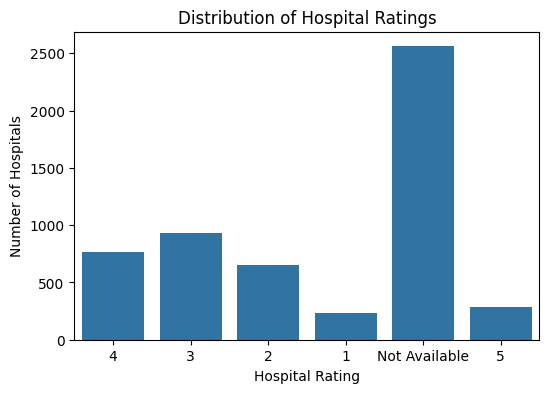

In [165]:
plot_count_distribution(
    df,
    "Hospital overall rating",
    "Distribution of Hospital Ratings",
    "Hospital Rating",
    "Number of Hospitals"
)

In [166]:
df = replace_not_available(df)

In [167]:
df.isna().sum().sort_values(ascending=False)

TE Group Footnote                                   4486
READM Group Footnote                                4266
MORT Group Footnote                                 3639
Safety Group Footnote                               3347
Meets criteria for birthing friendly designation    3161
Pt Exp Group Footnote                               3151
Hospital overall rating footnote                    2854
Hospital overall rating                             2560
Count of Facility Pt Exp Measures                   2275
Count of Safety Measures Worse                      2073
Count of Safety Measures No Different               2073
Count of Safety Measures Better                     2073
Count of Facility Safety Measures                   2073
Count of Facility MORT Measures                     1786
Count of MORT Measures Better                       1786
Count of MORT Measures No Different                 1786
Count of MORT Measures Worse                        1786
Count of READM Measures Worse  

In [168]:
# Remove rows where the target variable (hospital rating) is missing
df = drop_missing_rows(df, ["Hospital overall rating"])

In [169]:
# Check dataset dimensions after removing missing ratings
df.shape

(2866, 38)

In [170]:
# Count how many hospitals fall into each rating category
df["Hospital overall rating"].value_counts()

Hospital overall rating
3    935
4    765
2    649
5    288
1    229
Name: count, dtype: int64

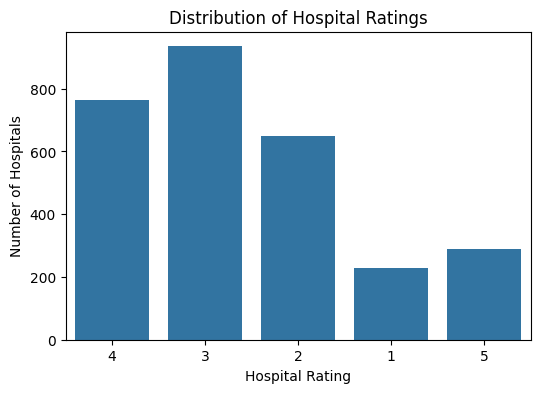

In [171]:
# Plot distribution of hospital ratings
plot_count_distribution(
    df,
    "Hospital overall rating",
    "Distribution of Hospital Ratings",
    "Hospital Rating",
    "Number of Hospitals"
)

### Distribution of Hospital Ratings

Most hospitals have a rating of 3 or 4. Lower ratings (1) and higher ratings (5) are less common, indicating that most hospitals fall into the middle performance range.

In [172]:
# Convert rating to numeric
df["Hospital overall rating"] = pd.to_numeric(df["Hospital overall rating"])

In [173]:
# Convert selected performance metrics to numeric
numeric_cols = [
    "Hospital overall rating",
    "Count of MORT Measures Better",
    "Count of MORT Measures Worse",
    "Count of Safety Measures Better",
    "Count of Safety Measures Worse",
    "Count of READM Measures Better",
    "Count of READM Measures Worse",
    "Count of MORT Measures No Different"
]

df = convert_columns_to_numeric(df, numeric_cols)

In [174]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2866 entries, 0 to 5405
Data columns (total 38 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Facility ID                                       2866 non-null   object 
 1   Facility Name                                     2866 non-null   object 
 2   Address                                           2866 non-null   object 
 3   City/Town                                         2866 non-null   object 
 4   State                                             2866 non-null   object 
 5   ZIP Code                                          2866 non-null   int64  
 6   County/Parish                                     2866 non-null   object 
 7   Telephone Number                                  2866 non-null   object 
 8   Hospital Type                                     2866 non-null   object 
 9   Hospital Ownership      

In [175]:
df.columns

Index(['Facility ID', 'Facility Name', 'Address', 'City/Town', 'State',
       'ZIP Code', 'County/Parish', 'Telephone Number', 'Hospital Type',
       'Hospital Ownership', 'Emergency Services',
       'Meets criteria for birthing friendly designation',
       'Hospital overall rating', 'Hospital overall rating footnote',
       'MORT Group Measure Count', 'Count of Facility MORT Measures',
       'Count of MORT Measures Better', 'Count of MORT Measures No Different',
       'Count of MORT Measures Worse', 'MORT Group Footnote',
       'Safety Group Measure Count', 'Count of Facility Safety Measures',
       'Count of Safety Measures Better',
       'Count of Safety Measures No Different',
       'Count of Safety Measures Worse', 'Safety Group Footnote',
       'READM Group Measure Count', 'Count of Facility READM Measures',
       'Count of READM Measures Better',
       'Count of READM Measures No Different', 'Count of READM Measures Worse',
       'READM Group Footnote', 'Pt Exp Gr

In [176]:
# Select numeric columns for correlation analysis
cols = [
    "Hospital overall rating",
    "Count of MORT Measures Better",
    "Count of MORT Measures Worse",
    "Count of MORT Measures No Different",
    "Count of Safety Measures Better",
    "Count of Safety Measures Worse",
    "Count of READM Measures Better",
    "Count of READM Measures Worse"
]

numeric_df = df[cols]

In [177]:
# Compute correlation matrix
corr = numeric_df.corr()

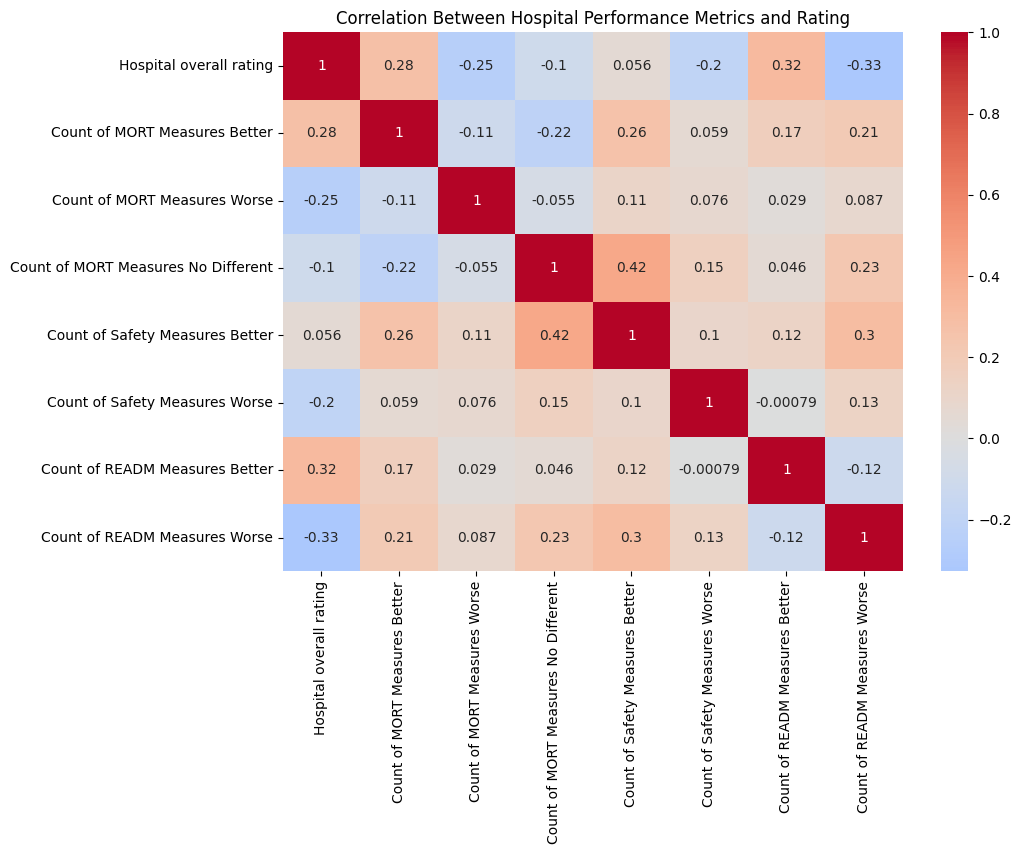

In [178]:
# Plot correlation heatmap
plot_correlation_heatmap(
    numeric_df,
    "Correlation Between Hospital Performance Metrics and Rating"
)

### Correlation Insights

The correlation analysis shows that readmission and mortality performance metrics have the strongest relationships with hospital overall ratings.

Hospitals with more measures categorized as "Better" tend to have higher ratings, while hospitals with more measures categorized as "Worse" tend to have lower ratings.

Although the correlations are moderate, these variables may still provide useful predictive information for a machine learning model.

## Feature Selection

The dataset contains several categorical variables such as **Hospital Type**, **Hospital Ownership**, and **Emergency Services**.

For this analysis, the model focuses on numerical hospital performance indicators related to mortality, safety, and readmission measures.

Categorical variables were excluded from the model to simplify the analysis and focus on measurable performance metrics.

Future work could incorporate these variables using techniques such as **one-hot encoding** to evaluate whether hospital type or ownership influences overall ratings.

In [179]:
# Define target variable
y = df["Hospital overall rating"]

# Define feature variables
X = df[[
    "Count of MORT Measures Better",
    "Count of MORT Measures Worse",
    "Count of MORT Measures No Different",
    "Count of Safety Measures Better",
    "Count of Safety Measures Worse",
    "Count of READM Measures Better",
    "Count of READM Measures Worse"
]]

In [180]:
# Check missing values in selected features
X.isna().sum()

Count of MORT Measures Better          53
Count of MORT Measures Worse           53
Count of MORT Measures No Different    53
Count of Safety Measures Better        85
Count of Safety Measures Worse         85
Count of READM Measures Better          1
Count of READM Measures Worse           1
dtype: int64

## Handling Missing Values

Some rows contained missing values in key variables such as the hospital rating or quality metrics.

Rows with missing values were removed because:

- The percentage of missing data was relatively small compared to the full dataset.
- Imputing hospital ratings could introduce bias into the target variable.
- Removing incomplete records ensures that the machine learning model is trained on reliable observations.

This approach helps maintain the integrity of the predictive analysis.

In [181]:
# Remove rows with missing values
model_data = drop_missing_rows(df, [
    "Hospital overall rating",
    "Count of MORT Measures Better",
    "Count of MORT Measures Worse",
    "Count of MORT Measures No Different",
    "Count of Safety Measures Better",
    "Count of Safety Measures Worse",
    "Count of READM Measures Better",
    "Count of READM Measures Worse"
])

y = model_data["Hospital overall rating"]
X = model_data[[
    "Count of MORT Measures Better",
    "Count of MORT Measures Worse",
    "Count of MORT Measures No Different",
    "Count of Safety Measures Better",
    "Count of Safety Measures Worse",
    "Count of READM Measures Better",
    "Count of READM Measures Worse"
]]

In [182]:

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [183]:
# Create Random Forest model
model = train_random_forest(X_train, y_train)

In [184]:
# Predict ratings on the test set
y_pred = model.predict(X_test)

In [185]:
# Compute accuracy
accuracy = accuracy_score(y_test, y_pred)

accuracy

0.39377289377289376

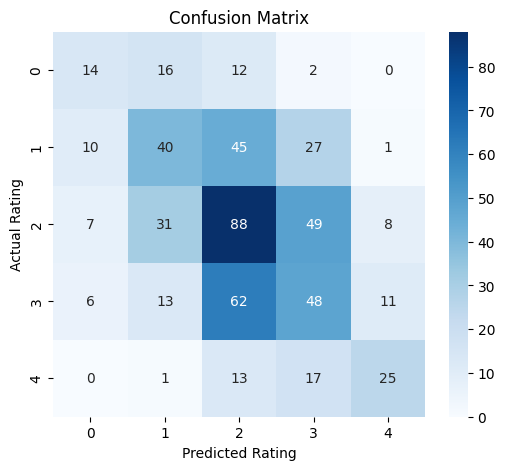

In [186]:
# Plot confusion matrix to evaluate classification performance

plot_conf_matrix(y_test, y_pred, "Confusion Matrix")

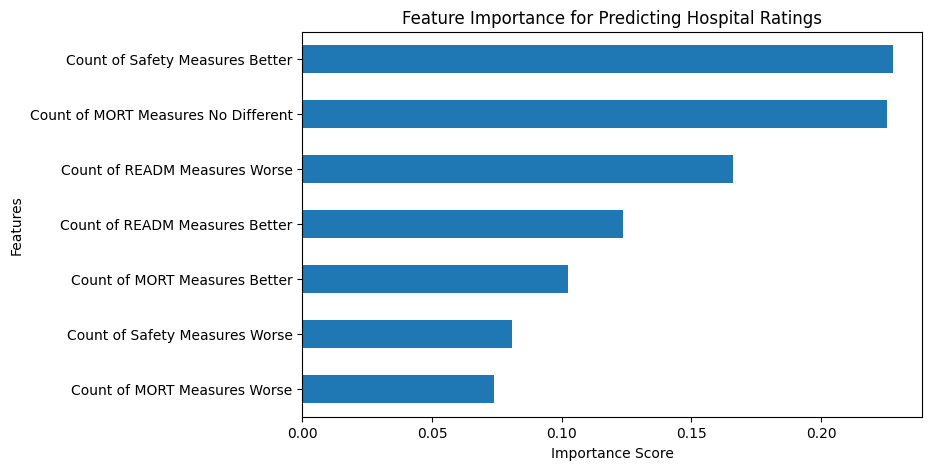

In [191]:
# Identify which variables influence the prediction the most
plot_feature_importance(
    feature_importance,
    "Feature Importance for Predicting Hospital Ratings"
)

In [188]:
# Generate precision, recall and F1-score for each rating class

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.38      0.32      0.35        44
           2       0.40      0.33      0.36       123
           3       0.40      0.48      0.44       183
           4       0.34      0.34      0.34       140
           5       0.56      0.45      0.50        56

    accuracy                           0.39       546
   macro avg       0.41      0.38      0.39       546
weighted avg       0.40      0.39      0.39       546



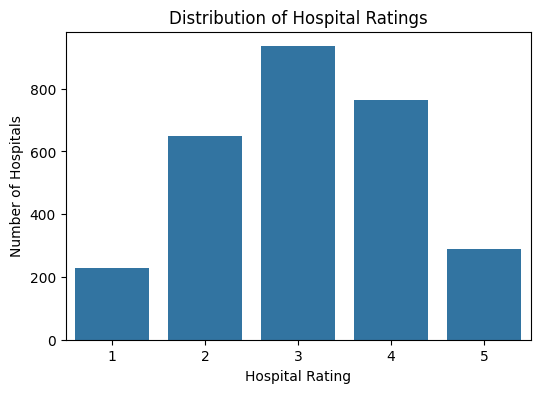

In [189]:
# Plot distribution of hospital ratings

plot_count_distribution(
    df,
    "Hospital overall rating",
    "Distribution of Hospital Ratings",
    "Hospital Rating",
    "Number of Hospitals"
)

In [190]:
# Predict on training data
y_train_pred = model.predict(X_train)

# Compute training accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)

train_accuracy

0.5971585701191567